<a href="https://colab.research.google.com/github/ByvatovS/ML_Task/blob/main/Diabetes_prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##About Dataset


1.   Gender refers to the biological sex of the individual, which can have an impact on their susceptibility to diabetes.
2.   Age is an important factor as diabetes is more commonly diagnosed in older adults.
3.   Hypertension is a medical condition in which the blood pressure in the arteries is persistently elevated
4.   Heart disease is another medical condition that is associated with an increased risk of developing diabetes.
5.   Smoking history is also considered a risk factor for diabetes and can exacerbate the complications associated.
6.    BMI (Body Mass Index) is a measure of body fat based on weight and height.
7.   HbA1c (Hemoglobin A1c) level is a measure of a person's average blood sugar level over the past 2-3 months.
8.   Blood glucose level refers to the amount of glucose in the bloodstream at a given time.
9.   Diabetes is the target variable being predicted, with values of 1 indicating the presence of diabetes and 0

In [30]:
#!unzip diabetes_data.zip

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [32]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
df1 = df.copy()
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [33]:
df['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


In [34]:
df.shape

(100000, 9)

In [35]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [36]:
df['gender'].value_counts()

,count
gender,
Female,56161
Male,39967
Other,18


In [37]:
df = df[df['gender'] != "Other"]

In [38]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [39]:
df['smoking_history'].value_counts()

,count
smoking_history,
never,34395
No Info,32881
former,9299
current,9197
not current,6359
ever,3997


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  object 
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  object 
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [41]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000
mean,41.796617,0.077615,0.040810,27.321450,5.532633,138.218001,0.088237
std,22.463329,0.267567,0.197851,6.767811,1.073225,40.911190,0.283640
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [42]:
df1 = df.copy()

encoder = LabelEncoder()
df1['gender'] = encoder.fit_transform(df1['gender'])
df1['smoking_history'] = encoder.fit_transform(df1['smoking_history'])
df1.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


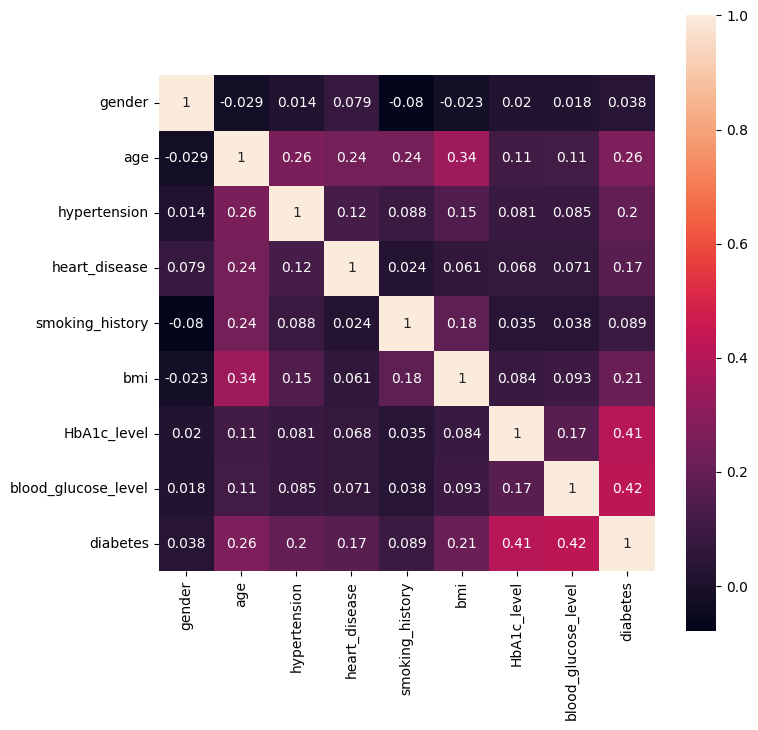

In [43]:
corr_matr = df1.corr()
plt.figure(figsize = (8,8))
sns.heatmap(corr_matr , square = True, annot=True)
plt.show()

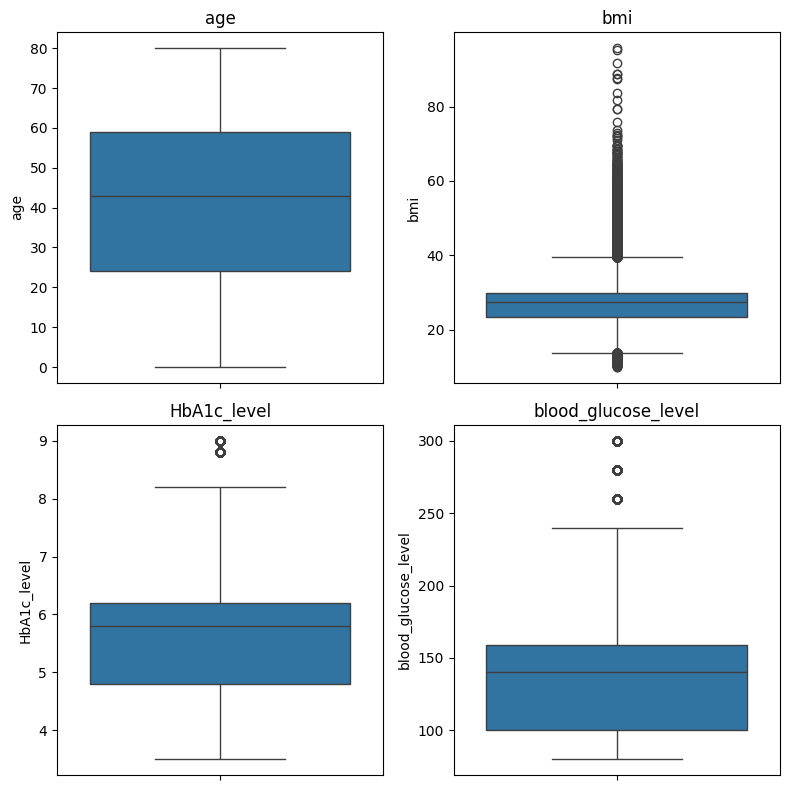

In [44]:
num_cols = ['age' ,'bmi' , 'HbA1c_level' , 'blood_glucose_level' ]

fig , axs = plt.subplots(2 , 2, figsize = (8 , 8))
axs = axs.flatten()
for ind , col in enumerate(num_cols):
      sns.boxplot(y=df[col], ax=axs[ind])
      axs[ind].set_title(col)
plt.tight_layout()
plt.show()


In [45]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
low_bound = Q1 - 3 * IQR
up_bound = Q3 + 3 * IQR

df = df[(df['bmi'] > low_bound) & (df['bmi'] < up_bound)]

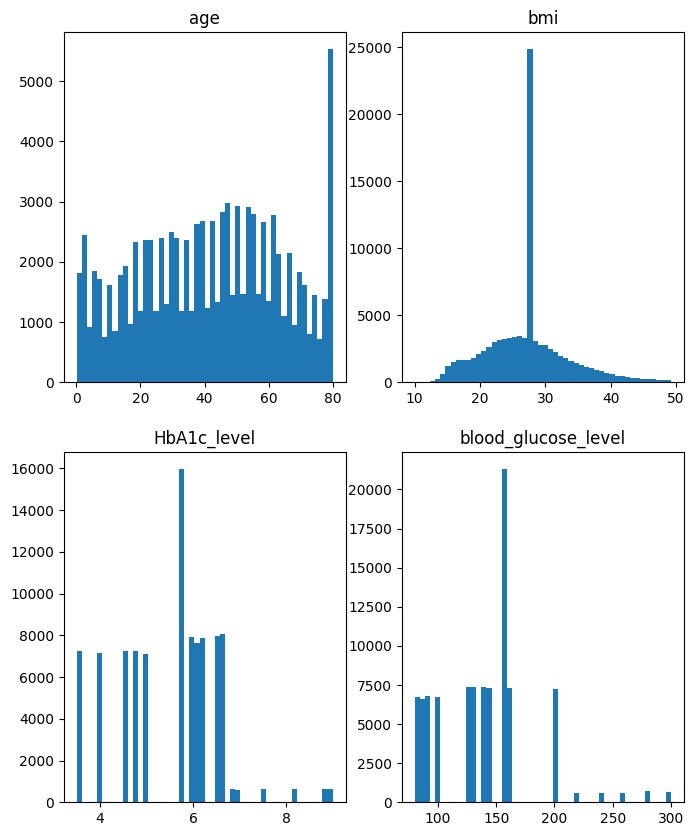

In [46]:
fig , axs = plt.subplots(2 , 2 , figsize=(8,10))
axs = axs.flatten()
for ind , col in enumerate(num_cols):
  axs[ind].hist(df[col], bins = 50)
  axs[ind].set_title(col)

plt.show()


In [47]:
cat_cols = ['gender' , 'hypertension' , 'heart_disease' ,'smoking_history' ]
num_cols = ['age' , 'bmi' , 'HbA1c_level' ,'blood_glucose_level' ]

X = df.drop(['diabetes'] , axis = 1)
y = df['diabetes']
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state= 42)

In [48]:
# !pip install optuna

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import optuna

In [50]:
eval_res = []
def eval_model(name ,y_test, y_pred, y_prob = None):
  res = {"Model_Name" : name ,
         "Accuracy" : accuracy_score(y_test , y_pred),
         "Precision" : precision_score(y_test , y_pred ,zero_division = 1),
         "Recall" : recall_score(y_test , y_pred ,zero_division = 1) ,
         "F1-score": f1_score(y_test , y_pred ,zero_division=1)
        }
  if y_prob is not None:
    res["ROC_AUC"] = roc_auc_score(y_test , y_prob)
  else:
    res["ROC_AUC"] = None
  eval_res.append(res)

In [51]:
def PrintMetrics(l):
  for i in range(len(l)):
    for k in l[i].keys():
      print(f"{k}  :   {l[i][k]}")
    print()



In [52]:
ohe = OneHotEncoder(handle_unknown= "ignore")
train_enc = ohe.fit_transform(X_train[cat_cols]).toarray()
test_enc = ohe.transform(X_test[cat_cols]).toarray()

scaler = StandardScaler()
train_scaler = scaler.fit_transform(X_train[num_cols])
test_scaler = scaler.transform(X_test[num_cols])


X_train_fin = np.concatenate((train_enc , train_scaler) , axis = 1)
X_test_fin = np.concatenate((test_enc , test_scaler) , axis = 1)


In [53]:
def objective_LogReg(trial):
  C =trial.suggest_loguniform('C' ,1e-4 , 1e+2)
  solver = trial.suggest_categorical('solver' , ['saga' , 'liblinear' , 'lbfgs'])

  model = LogisticRegression(C = C , solver = solver , max_iter = 500, random_state = 42 )
  score = cross_val_score(model , X_train_fin , y_train , cv = 3, scoring = 'accuracy').mean()

  return score

study = optuna.create_study(direction = 'maximize')
study.optimize(objective_LogReg, n_trials = 30)

best_params = study.best_params
best_model =  LogisticRegression(**best_params, max_iter = 500, random_state = 42 )
best_model.fit(X_train_fin , y_train)

[I 2025-03-29 07:36:42,178] A new study created in memory with name: no-name-61bc0dad-f939-4977-9031-feef6ff985a6
<ipython-input-53-f4e1c9b9a428>:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C =trial.suggest_loguniform('C' ,1e-4 , 1e+2)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2025-03-29 07:37:33,110] Trial 0 finished with value: 0.95997269373662

LogisticRegression(C=0.032699235210494226, max_iter=500, random_state=42)

In [54]:
y_pred = best_model.predict(X_test_fin)
y_prob = best_model.predict_proba(X_test_fin)[:, 1]
eval_model("Logistic Reg" , y_test, y_pred , y_prob)
print(best_params)
PrintMetrics(eval_res)

{'C': 0.032699235210494226, 'solver': 'lbfgs'}
Model_Name  :   Logistic Reg
Accuracy  :   0.9590422180214241
Precision  :   0.8717948717948718
Recall  :   0.6181818181818182
F1-score  :   0.723404255319149
ROC_AUC  :   0.9623459674356534



In [55]:
from sklearn.ensemble import RandomForestClassifier

def objective_RFC(trial):
  param_grid = {
      "n_estimators": trial.suggest_int("n_estimators" , 50 , 500 , step = 50),
      "max_depth": trial.suggest_int("max_depth" , 5 , 30),
      "criterion": trial.suggest_categorical('criterion' , ['gini' , 'entropy' , 'log_loss']),
      "min_samples_split": trial.suggest_int("min_samples_split" , 2 , 50),
      "min_samples_leaf": trial.suggest_int("min_samples_leaf" , 1 , 20),
      "max_features": trial.suggest_categorical("max_features" , ['sqrt' , 'log2' ,0.7 , 0.5]),
      'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])
      }

  model = RandomForestClassifier(**param_grid, random_state= 42 , n_jobs= -1)
  score = cross_val_score(model , X_train_fin , y_train , cv = 3 , scoring = "accuracy").mean()

  return score

study = optuna.create_study(direction = "maximize")
study.optimize(objective_RFC , n_trials = 30)

best_params_RFC = study.best_params
best_model = RandomForestClassifier(**best_params_RFC, random_state= 42 , n_jobs= -1)
best_model.fit(X_train_fin , y_train)


[I 2025-03-29 07:39:32,917] A new study created in memory with name: no-name-3d8c2c69-77bb-485f-9bfd-b4c4f3bb8ed0
[I 2025-03-29 07:40:07,823] Trial 0 finished with value: 0.957110787286834 and parameters: {'n_estimators': 150, 'max_depth': 27, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 0.7, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.957110787286834.
[I 2025-03-29 07:40:21,232] Trial 1 finished with value: 0.9084715056516087 and parameters: {'n_estimators': 100, 'max_depth': 12, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 17, 'max_features': 0.5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.957110787286834.
[I 2025-03-29 07:40:44,299] Trial 2 finished with value: 0.9716172397043573 and parameters: {'n_estimators': 150, 'max_depth': 28, 'criterion': 'log_loss', 'min_samples_split': 32, 'min_samples_leaf': 11, 'max_features': 0.5, 'class_weight': None}. Best is trial 2 with value: 

RandomForestClassifier(criterion='log_loss', max_depth=18, max_features=0.5,
                       min_samples_leaf=8, min_samples_split=43,
                       n_estimators=400, n_jobs=-1, random_state=42)

In [56]:
y_pred = best_model.predict(X_test_fin)
y_prob = best_model.predict_proba(X_test_fin)[:, 1]
eval_model("RFC" , y_test, y_pred , y_prob)
print(best_params_RFC)
PrintMetrics(eval_res)

{'n_estimators': 400, 'max_depth': 18, 'criterion': 'log_loss', 'min_samples_split': 43, 'min_samples_leaf': 8, 'max_features': 0.5, 'class_weight': None}
Model_Name  :   Logistic Reg
Accuracy  :   0.9590422180214241
Precision  :   0.8717948717948718
Recall  :   0.6181818181818182
F1-score  :   0.723404255319149
ROC_AUC  :   0.9623459674356534

Model_Name  :   RFC
Accuracy  :   0.9708044528460408
Precision  :   0.9927927927927928
Recall  :   0.6678787878787878
F1-score  :   0.7985507246376812
ROC_AUC  :   0.9778154954163922



In [57]:
!pip install catboost

In [58]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [59]:
from catboost import CatBoostClassifier, Pool
cat_cols = ['gender' , 'hypertension' , 'heart_disease' ,'smoking_history' ]
num_cols = ['age' , 'bmi' , 'HbA1c_level' ,'blood_glucose_level' ]

train_data = Pool(data=X_train, label=y_train, cat_features=cat_cols)

cat = CatBoostClassifier()
params ={
    "iterations": np.arange(50 , 300 , 50),
    "learning_rate": np.arange(0.01 , 0.2 , 0.05),
    "min_data_in_leaf": np.arange(1 , 20, 5),
    "depth": np.arange(2 , 5),
}

grid_search_result = cat.grid_search(params, X=train_data , cv = 3)
best_params = grid_search_result['params']
cat = CatBoostClassifier(**best_params, random_state = 42)
cat.fit(train_data)

Выходные данные были обрезаны до нескольких последних строк (5000).
146:	learn: 0.0793497	test: 0.0794491	best: 0.0794464 (139)	total: 8.14s	remaining: 2.94s
147:	learn: 0.0793472	test: 0.0794497	best: 0.0794464 (139)	total: 8.19s	remaining: 2.88s
148:	learn: 0.0793312	test: 0.0794534	best: 0.0794464 (139)	total: 8.23s	remaining: 2.82s
149:	learn: 0.0793157	test: 0.0794577	best: 0.0794464 (139)	total: 8.28s	remaining: 2.76s
150:	learn: 0.0793147	test: 0.0794589	best: 0.0794464 (139)	total: 8.32s	remaining: 2.7s
151:	learn: 0.0793113	test: 0.0794632	best: 0.0794464 (139)	total: 8.37s	remaining: 2.64s
152:	learn: 0.0792911	test: 0.0794547	best: 0.0794464 (139)	total: 8.4s	remaining: 2.58s
153:	learn: 0.0792827	test: 0.0794518	best: 0.0794464 (139)	total: 8.44s	remaining: 2.52s
154:	learn: 0.0792475	test: 0.0794381	best: 0.0794381 (154)	total: 8.48s	remaining: 2.46s
155:	learn: 0.0792475	test: 0.0794381	best: 0.0794381 (154)	total: 8.52s	remaining: 2.4s
156:	learn: 0.0792422	test: 0.07944

In [60]:
y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]
eval_model("CatBoost" , y_test, y_pred , y_prob)
print(best_params)
PrintMetrics(eval_res)

{'min_data_in_leaf': 1, 'depth': 4, 'learning_rate': 0.11, 'iterations': 150}
Model_Name  :   Logistic Reg
Accuracy  :   0.9590422180214241
Precision  :   0.8717948717948718
Recall  :   0.6181818181818182
F1-score  :   0.723404255319149
ROC_AUC  :   0.9623459674356534

Model_Name  :   RFC
Accuracy  :   0.9708044528460408
Precision  :   0.9927927927927928
Recall  :   0.6678787878787878
F1-score  :   0.7985507246376812
ROC_AUC  :   0.9778154954163922

Model_Name  :   CatBoost
Accuracy  :   0.9706469229153539
Precision  :   0.9840283939662822
Recall  :   0.6721212121212121
F1-score  :   0.7987036370183651
ROC_AUC  :   0.9799327180044668

